# ERA5 to PRISM Downscaling (Georgia)

## Problem Setup

ERA5 provides coarse atmospheric fields, and PRISM provides higher-resolution temperature targets. The goal is supervised regional downscaling: map ERA5 state to PRISM near-surface temperature over Georgia.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "datasets").exists() and (ROOT.parent / "datasets").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Project root: {ROOT}")


Project root: /private/tmp/robust-earth-forecast-work


## Data Used

- ERA5 monthly NetCDF data over Georgia (single-level and pressure-level variables)
- PRISM daily rasters as the high-resolution target
- Paired samples built as `[T, C, H, W] -> [1, H_high, W_high]`


In [2]:
import json
import pandas as pd
import xarray as xr
from IPython.display import Image, Markdown, display

from datasets.prism_dataset import ERA5_PRISM_Dataset

ERA5_PATH = ROOT / "data_raw/era5_georgia_temp.nc"
PRISM_DIR = ROOT / "data_raw/prism"
EVAL_DIR = ROOT / "results/evaluation"
TRAIN_DIR = ROOT / "results/training_logs"
TUNE_DIR = ROOT / "results/tuning"
TEMPORAL_DIR = ROOT / "results/temporal_analysis"
ABLATION_DIR = ROOT / "results/ablation"
VIS_DIR = ROOT / "results/visualizations"

if ERA5_PATH.exists() and PRISM_DIR.exists():
    ds_era5 = xr.open_dataset(ERA5_PATH)
    print("ERA5 variables:", list(ds_era5.data_vars))
    ds = ERA5_PRISM_Dataset(str(ERA5_PATH), str(PRISM_DIR), history_length=3, input_set="extended", verbose=False)
    x, y = ds[0]
    print("Extended input shape [T, C, H, W]:", tuple(x.shape))
    print("Target shape [C, H, W]:", tuple(y.shape))
else:
    print("Data missing. Run:")
    print("python data_pipeline/download_era5_georgia.py --year 2023 --month 1 --overwrite")
    print("python data_pipeline/download_prism.py --start-date 20230101 --days 30 --variable tmean")


ERA5 variables: ['tp', 't2m', 'd2m', 'u10', 'v10', 'sp', 'rh2m', 'temperature_850', 'temperature_500', 'geopotential_height_850', 'geopotential_height_500', 'relative_humidity_850', 'relative_humidity_500']


Extended input shape [T, C, H, W]: (3, 12, 21, 21)
Target shape [C, H, W]: (1, 121, 121)


## Why These Variables

`t2m` is the direct target proxy, while `u10/v10` and `sp` add near-surface dynamical context. Extended inputs (`tp`, humidity, pressure-level temperature and geopotential height) add moisture and vertical-structure information that helps constrain surface temperature patterns.

## Model Family

- persistence: reference baseline
- linear: simple parametric baseline
- cnn: spatial coarse-to-fine mapping
- convlstm: spatial + temporal sequence modeling

ConvLSTM is used to test whether temporal ERA5 context improves downscaling relative to purely spatial models.

## Why This Setup Is Reasonable

Downscaling is a coarse-to-fine learning problem. Multi-variable conditioning is needed because near-surface temperature depends on circulation, moisture, and pressure structure. Temporal context is needed because atmospheric state evolves over time. Train-split normalization and fixed-split evaluation make model comparisons credible.


### CNN loss curve

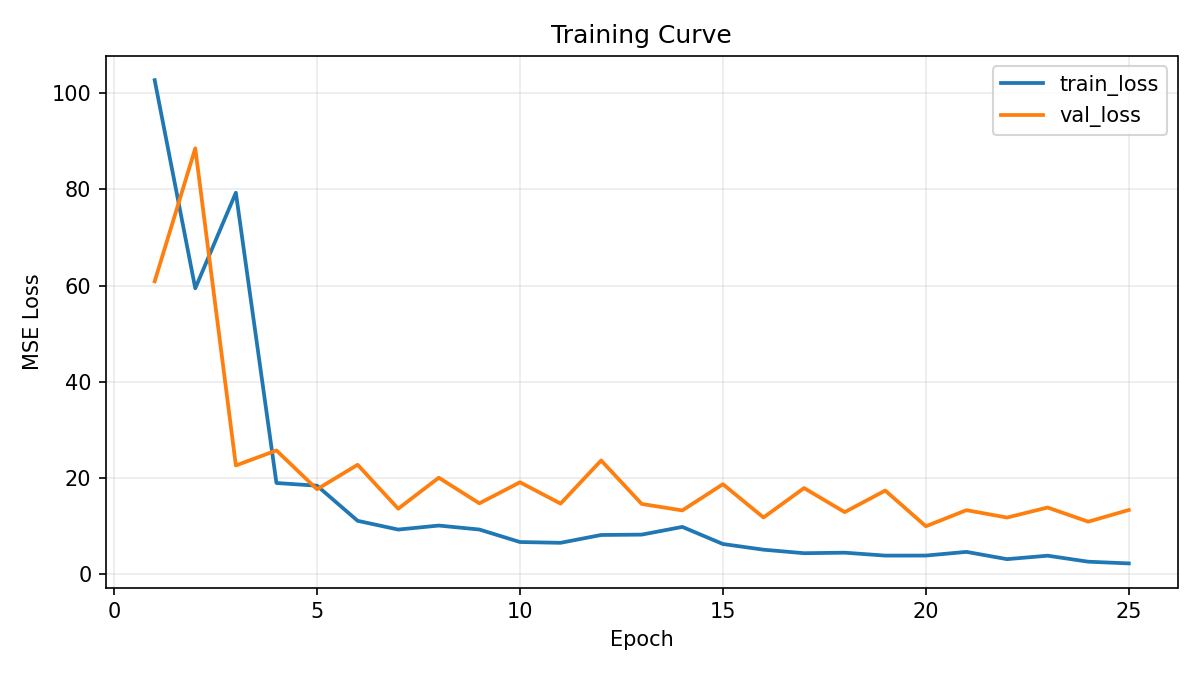

### ConvLSTM loss curve

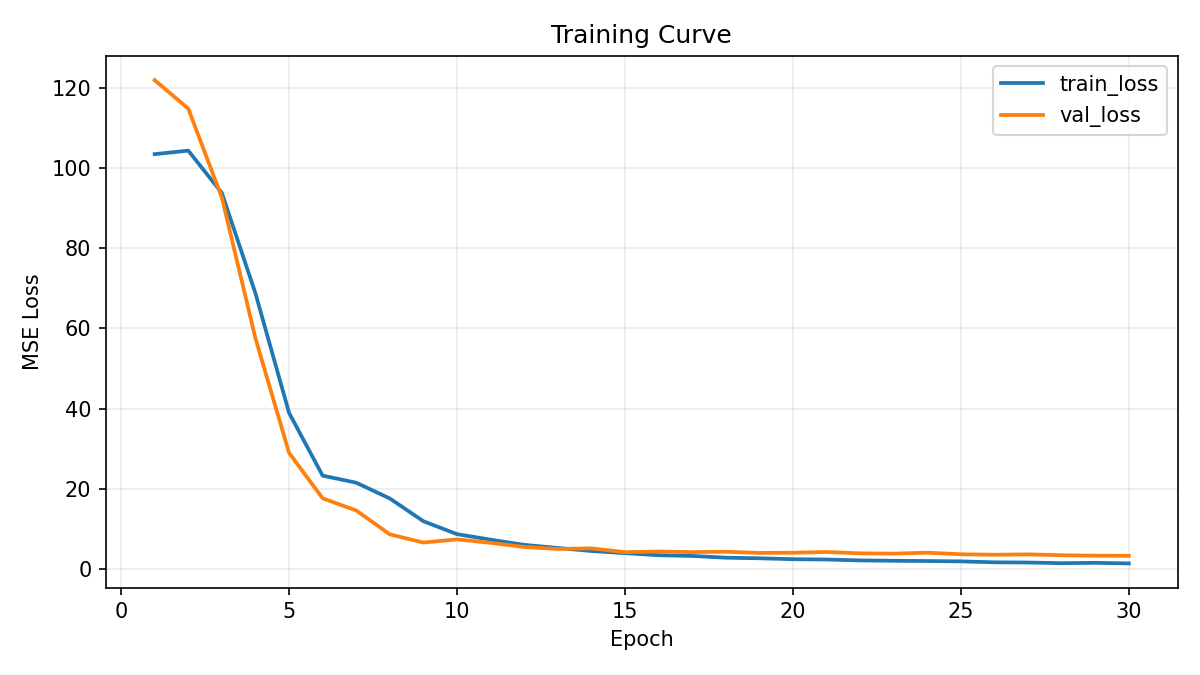

,model,best_val_loss
0,cnn,9.957508
1,convlstm,3.341111


In [3]:
cnn_curve = TRAIN_DIR / "cnn_loss_curve.png"
convlstm_curve = TRAIN_DIR / "convlstm_loss_curve.png"
cnn_log = TRAIN_DIR / "cnn_training_log.csv"
convlstm_log = TRAIN_DIR / "convlstm_training_log.csv"

if cnn_curve.exists():
    display(Markdown("### CNN loss curve"))
    display(Image(filename=str(cnn_curve)))
if convlstm_curve.exists():
    display(Markdown("### ConvLSTM loss curve"))
    display(Image(filename=str(convlstm_curve)))

if cnn_log.exists() and convlstm_log.exists():
    cdf = pd.read_csv(cnn_log)
    vdf = pd.read_csv(convlstm_log)
    summary = pd.DataFrame([
        {"model": "cnn", "best_val_loss": float(cdf["val_loss"].min())},
        {"model": "convlstm", "best_val_loss": float(vdf["val_loss"].min())},
    ])
    display(summary)
else:
    print("Run final training commands from README first.")


## Training and Tuning

Early weak runs were addressed by longer training, scheduler use, gradient clipping, weight decay, and consistent split control. The next cells summarize loss curves and the tuning sweep used to stabilize training.


In [4]:
tune_csv = TUNE_DIR / "tuning_summary.csv"
best_json = TUNE_DIR / "best_config.json"

if tune_csv.exists():
    tune_df = pd.read_csv(tune_csv)
    tune_df = tune_df[tune_df["status"] == "ok"].sort_values("best_val_loss")
    display(Markdown("### Top sweep runs"))
    display(tune_df[["run_name", "model", "history_length", "learning_rate", "weight_decay", "best_val_loss"]].head(10))
if best_json.exists():
    display(Markdown("### Best config"))
    display(json.loads(best_json.read_text()))


### Top sweep runs

,run_name,model,history_length,learning_rate,weight_decay,best_val_loss
13,convlstm_h3_lr1e-03_wd1e-05,convlstm,3,0.0010,0.00001,4.060254
12,convlstm_h3_lr1e-03_wd0e+00,convlstm,3,0.0010,0.00000,4.060536
14,convlstm_h3_lr5e-04_wd0e+00,convlstm,3,0.0005,0.00000,5.376289
15,convlstm_h3_lr5e-04_wd1e-05,convlstm,3,0.0005,0.00001,5.378856
18,convlstm_h6_lr1e-03_wd0e+00,convlstm,6,0.0010,0.00000,5.789028
19,convlstm_h6_lr1e-03_wd1e-05,convlstm,6,0.0010,0.00001,5.795527
21,convlstm_h6_lr5e-04_wd1e-05,convlstm,6,0.0005,0.00001,7.912377
20,convlstm_h6_lr5e-04_wd0e+00,convlstm,6,0.0005,0.00000,7.913084
6,cnn_h6_lr1e-03_wd0e+00,cnn,6,0.0010,0.00000,9.145234
7,cnn_h6_lr1e-03_wd1e-05,cnn,6,0.0010,0.00001,9.483569


### Best config

{'search_space_size': 24,
 'best_overall': {'run_name': 'convlstm_h3_lr1e-03_wd1e-05',
  'model': 'convlstm',
  'input_set': 'extended',
  'history_length': 3,
  'learning_rate': 0.001,
  'weight_decay': 1e-05,
  'epochs': 20,
  'status': 'ok',
  'best_val_loss': 4.060253977775574,
  'best_epoch': 19,
  'checkpoint': 'results/tuning/checkpoints_tmp/convlstm_h3_lr1e-03_wd1e-05.pt'},
 'best_by_model': {'cnn': {'run_name': 'cnn_h6_lr1e-03_wd0e+00',
   'model': 'cnn',
   'input_set': 'extended',
   'history_length': 6,
   'learning_rate': 0.001,
   'weight_decay': 0.0,
   'epochs': 20,
   'status': 'ok',
   'best_val_loss': 9.145233869552612,
   'best_epoch': 17,
   'checkpoint': 'results/tuning/checkpoints_tmp/cnn_h6_lr1e-03_wd0e+00.pt'},
  'convlstm': {'run_name': 'convlstm_h3_lr1e-03_wd1e-05',
   'model': 'convlstm',
   'input_set': 'extended',
   'history_length': 3,
   'learning_rate': 0.001,
   'weight_decay': 1e-05,
   'epochs': 20,
   'status': 'ok',
   'best_val_loss': 4.060253977

## Temporal Analysis

History-length experiments (`1`, `3`, `6`) test how much temporal context contributes to each model family.


In [5]:
temporal_csv = TEMPORAL_DIR / "temporal_summary.csv"
if temporal_csv.exists():
    temporal_df = pd.read_csv(temporal_csv)
    display(temporal_df)
    pivot = temporal_df.pivot(index="history_length", columns="model", values="rmse")
    display(Markdown("### RMSE by history length"))
    display(pivot)
else:
    print("Run: python training/run_temporal_analysis.py --input-set extended --histories 1 3 6")


,model,history_length,input_set,epochs,learning_rate,weight_decay,best_val_loss,rmse,mae,bias,correlation
0,cnn,1,extended,20,0.001,0.00000,14.870032,3.704955,2.975000,-0.050517,0.340278
1,convlstm,1,extended,25,0.001,0.00001,21.222609,4.577054,3.791086,-0.217638,0.401563
2,cnn,3,extended,20,0.001,0.00000,9.957508,3.121144,2.565799,-1.504305,0.626129
3,convlstm,3,extended,25,0.001,0.00001,3.719863,1.858295,1.448509,0.065483,0.710002
4,cnn,6,extended,20,0.001,0.00000,8.752294,3.255909,2.911499,-0.425232,0.588737
5,convlstm,6,extended,25,0.001,0.00001,4.105245,1.935932,1.613837,0.008234,0.818509


### RMSE by history length

model,cnn,convlstm
history_length,,
1,3.704955,4.577054
3,3.121144,1.858295
6,3.255909,1.935932


## Ablation Study

Input-set ablation compares `t2m`, `core4`, and `extended` feature groups to quantify the value of richer atmospheric context.


In [6]:
ablation_csv = ABLATION_DIR / "ablation_summary.csv"
if ablation_csv.exists():
    ab_df = pd.read_csv(ablation_csv)
    display(ab_df)
else:
    print("Run: python training/run_ablation.py --model convlstm --input-sets t2m core4 extended --history-length 6")


,model,input_set,history_length,epochs,learning_rate,weight_decay,best_val_loss,rmse,mae,bias,correlation
0,convlstm,t2m,6,25,0.001,0.00001,6.437244,2.631730,2.244837,1.374428,0.744929
1,convlstm,core4,6,25,0.001,0.00001,10.287795,3.114004,2.776070,0.666312,0.698454
2,convlstm,extended,6,25,0.001,0.00001,4.105245,1.935932,1.613837,0.008234,0.818509


## Results

This section loads final evaluation metrics and visual outputs:
- `baselines_summary.csv`
- `model_comparison.png`
- `sample_prediction.png`
- `error_map.png`

Best model on the fair split is ConvLSTM (RMSE 1.749, MAE 1.377, CORR 0.778).


,model,rmse,mae,bias,correlation,num_samples,history_length
0,persistence,3.251017,2.610578,1.446135,0.640448,6,3
1,linear,2.964921,2.604944,-0.481662,0.640448,6,3
2,cnn,3.121144,2.565799,-1.504305,0.626129,6,3
3,convlstm,1.748717,1.376469,-0.187628,0.778366,6,3


### Model comparison

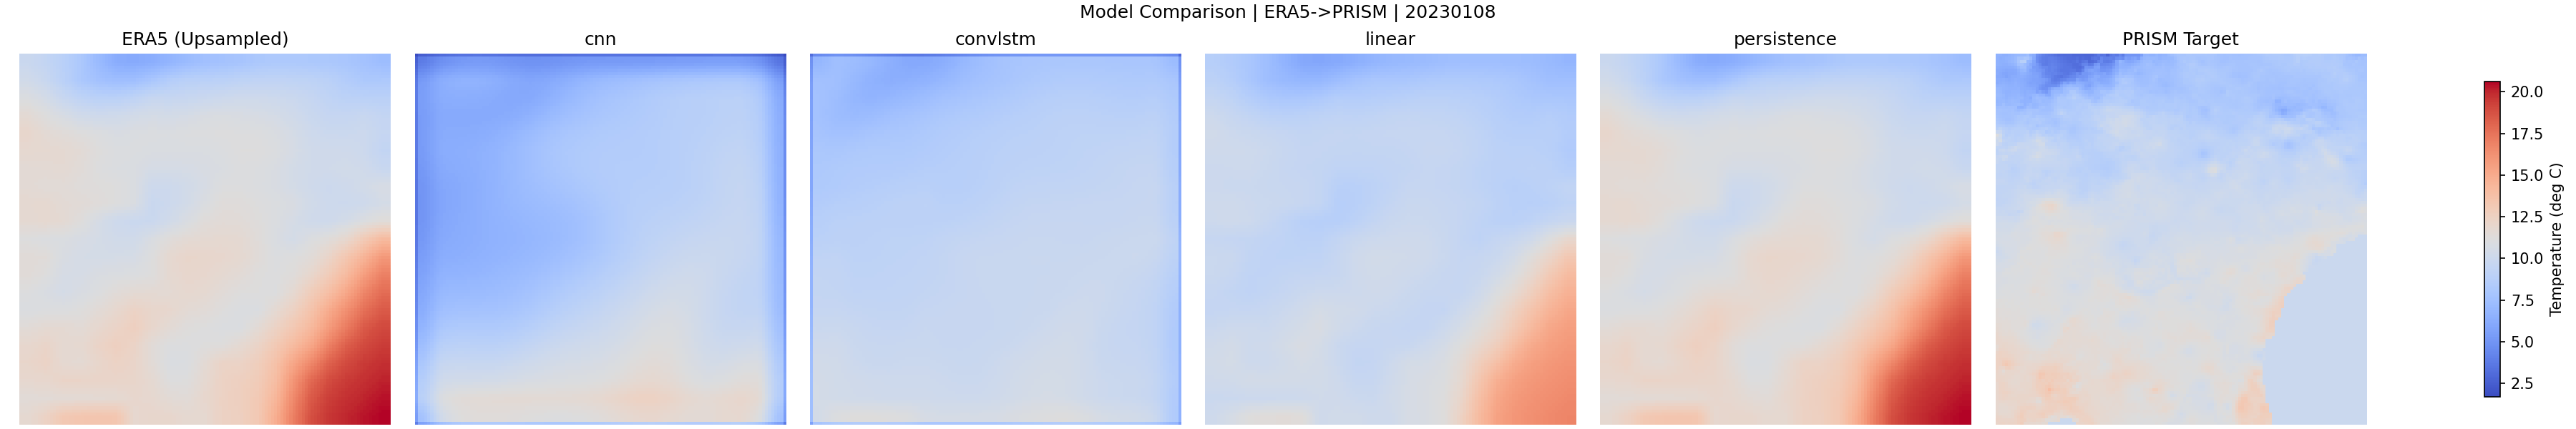

### Sample prediction

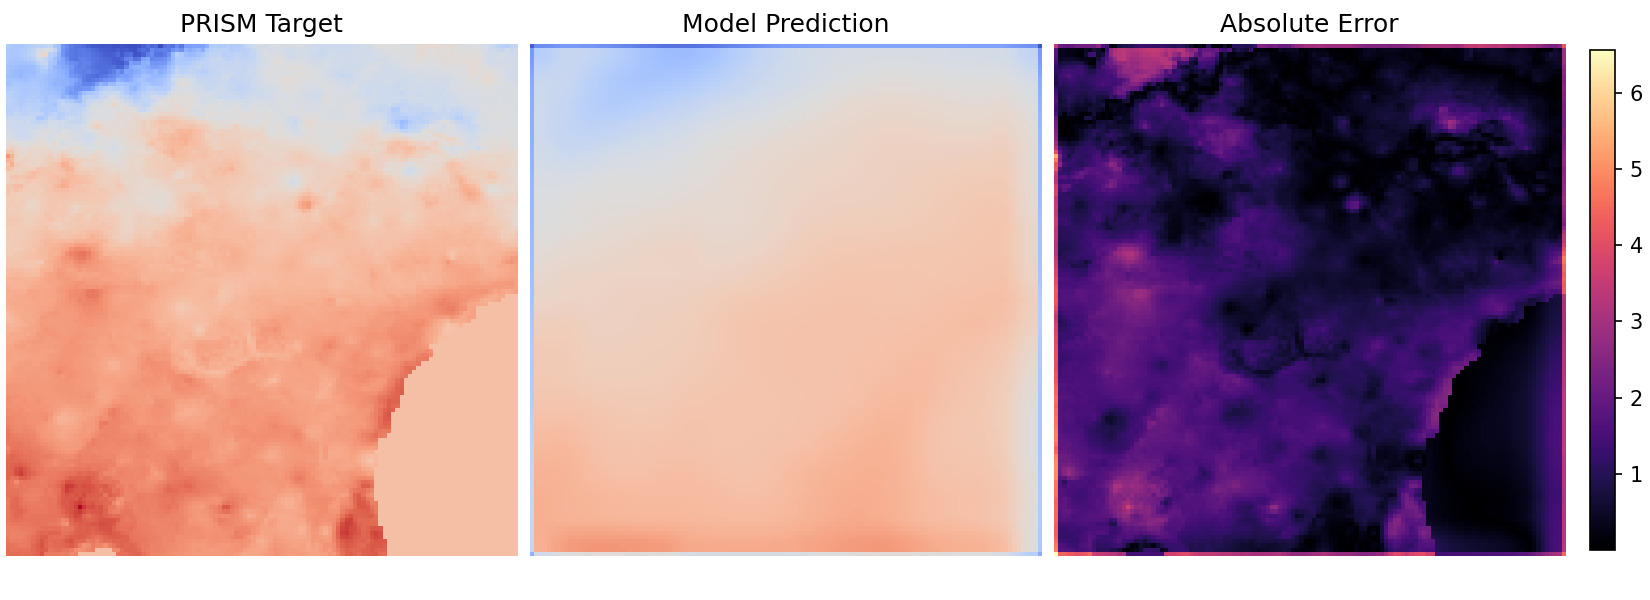

### Error map

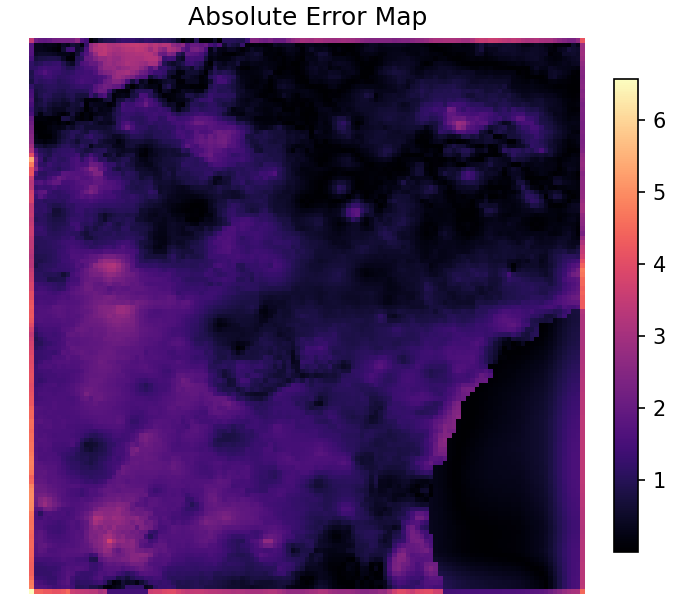

In [7]:
summary_csv = EVAL_DIR / "baselines_summary.csv"
comparison_img = EVAL_DIR / "model_comparison.png"
sample_img = VIS_DIR / "sample_prediction.png"
err_img = VIS_DIR / "error_map.png"

if summary_csv.exists():
    display(pd.read_csv(summary_csv))
if comparison_img.exists():
    display(Markdown("### Model comparison"))
    display(Image(filename=str(comparison_img)))
if sample_img.exists():
    display(Markdown("### Sample prediction"))
    display(Image(filename=str(sample_img)))
if err_img.exists():
    display(Markdown("### Error map"))
    display(Image(filename=str(err_img)))


## Relation to Existing Work

This pipeline follows a DeepSD-style formulation: supervised coarse-to-fine downscaling from low-resolution atmospheric fields to higher-resolution regional targets using CNN-family models.

It is also aligned with modern multi-variable temporal weather/climate modeling directions (including Prithvi WxC-style reasoning). The scope here is a smaller regional supervised system trained from scratch, not a large pretrained foundation model.


## Key Takeaways

- Richer multi-variable inputs improve ConvLSTM performance in ablation (`extended` best).
- Temporal context improves ConvLSTM versus short-history setup.
- Training stability changes were necessary to reach competitive deep-model performance.
- On the current fair split, ConvLSTM is strongest among evaluated models.
